HOUSE PRICE PREDICTION 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv(r"C:\Users\mdev0\Documents\JupyterNotebooks\data.csv")
df.head()
print(df.shape)
df.columns

(4600, 18)


Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [ ]:
df['city'].nunique()

44

In [ ]:
df['statezip'].nunique(),df['street'].nunique()

(77, 4525)

In [ ]:
# df['city'].unique(),df['statezip'].unique()

In [ ]:
df = pd.get_dummies(df, columns=['city', 'statezip'], drop_first=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Columns: 135 entries, date to statezip_WA 98354
dtypes: bool(119), float64(4), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition',
       ...
       'statezip_WA 98155', 'statezip_WA 98166', 'statezip_WA 98168',
       'statezip_WA 98177', 'statezip_WA 98178', 'statezip_WA 98188',
       'statezip_WA 98198', 'statezip_WA 98199', 'statezip_WA 98288',
       'statezip_WA 98354'],
      dtype='object', length=135)

In [ ]:
[col for col in df.columns if col.startswith('city_')][:10]


['city_Auburn',
 'city_Beaux Arts Village',
 'city_Bellevue',
 'city_Black Diamond',
 'city_Bothell',
 'city_Burien',
 'city_Carnation',
 'city_Clyde Hill',
 'city_Covington',
 'city_Des Moines']

In [ ]:
df1=df.drop(['date','country','street'],axis=1)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Columns: 132 entries, price to statezip_WA 98354
dtypes: bool(119), float64(4), int64(9)
memory usage: 1001.9 KB


In [ ]:
df1.isnull().sum().sum()

0

<Axes: >

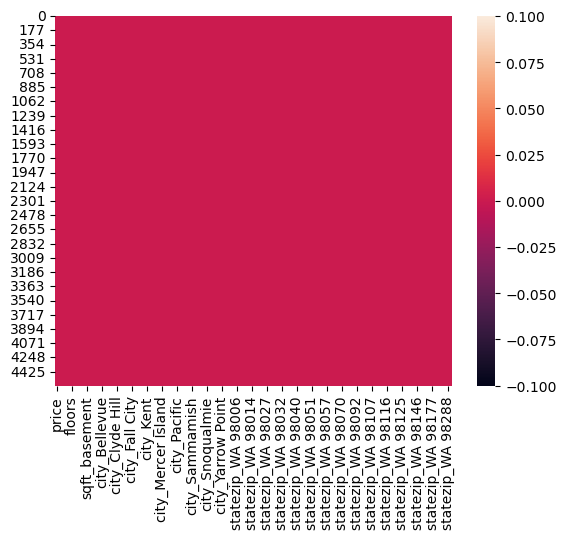

In [ ]:
sns.heatmap(df1.isnull())

In [ ]:
df1.shape

(4600, 132)

In [ ]:
df1.shape[0]

4600

In [ ]:
x=df1.drop('price',axis=1)
y=df1["price"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=51)
print("size of x_train:",x_train.shape)
print("size of y_train:",y_train.shape)



size of x_train: (3680, 131)
size of y_train: (3680,)


In [ ]:
sc=StandardScaler()
sc.fit(x_train)
x_train_sc=sc.transform(x_train)
x_test_sc=sc.transform(x_test)


In [ ]:
lr=LinearRegression()
lr.fit(x_train_sc,y_train)
lr.predict([x_train_sc[0,:]])
lr.score(x_test_sc,y_test)

-2.2911370263973537e+23

In [ ]:
rd=Ridge()
rd.fit(x_train_sc,y_train)
rd.score(x_test_sc,y_test)

0.07489258656165909

In [ ]:
rd=Lasso(alpha=1)
rd.fit(x_train_sc,y_train)
rd.score(x_test_sc,y_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.043e+14, tolerance: 6.726e+10
  model = cd_fast.enet_coordinate_descent(


0.07489712121731462

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

df1=df1[df1['price']>0]
X = df1.drop('price', axis=1)
y = np.log(df1['price'])
# y = df1['price']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
# sc=StandardScaler()
# sc.fit(X_train)
# X_train=sc.transform(X_train)
# X_test=sc.transform(X_test)

# rf.fit(x_train_sc, y_train)
# rf.score(x_test_sc,y_test)
rf.fit(X_train, y_train)
rf.score(X_test,y_test)


0.7191705851409823

In [ ]:
# from xgboost import XGBRegressor

# xgb = XGBRegressor(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# xgb.fit(x_train_sc, y_train)
# xgb.score(x_test_sc,y_test)

In [ ]:
(df['price']<=0).sum()

49

In [ ]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# df = df.drop(columns=['date', 'country','street'])
df1=df1[df1['price']>0]
X = df1.drop('price', axis=1)
y = np.log(df1['price'])
# y = df1['price']
# House prices are right-skewed and show multiplicative behavior
# . Log transformation reduces skewness, stabilizes variance, minimizes outlier impact, and improves linearity, leading to better generalization.”

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
# sc=StandardScaler()
# sc.fit(X_train)
# X_train=sc.transform(X_train)
# X_test=sc.transform(X_test)
# StandardScaler is not required for Random Forest and XGBoost because they are tree-based models that rely on feature ordering rather than distance. 
# Scaling does not affect split decisions, unlike linear or distance-based models.”
xgb.fit(X_train, y_train)

print("Train R2:", xgb.score(X_train, y_train))
print("Test R2:", xgb.score(X_test, y_test))


Train R2: 0.9196602322078483
Test R2: 0.7553782625360262


In [ ]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion="squared_error")
regressor.fit(X_train,y_train)
regressor.score(X_test,y_test)

0.5384397784169869